#🛠️ **Preparación de los Datos**

In [534]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

##**Extracción del Archivo Tratado**

In [535]:
df_clientes = pd.read_csv('/content/datos_tratados.csv')

In [536]:
df_clientes.head()

,customerID,Churn,Gender,>65,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily
0,0002-ORFBO,0,Female,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,Male,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,Male,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,1,Male,1,1,0,13,1,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,1,Female,1,1,0,3,1,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [537]:
df_clientes.shape

(7032, 22)

In [538]:
df_clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerID               7032 non-null   object 
 1   Churn                    7032 non-null   int64  
 2   Gender                   7032 non-null   object 
 3   >65                      7032 non-null   int64  
 4   Partner                  7032 non-null   int64  
 5   Dependents               7032 non-null   int64  
 6   Tenure                   7032 non-null   int64  
 7   PhoneService             7032 non-null   int64  
 8   MultipleLines            7032 non-null   object 
 9   InternetService          7032 non-null   object 
 10  internet.OnlineSecurity  7032 non-null   object 
 11  internet.OnlineBackup    7032 non-null   object 
 12  DeviceProtection         7032 non-null   object 
 13  TechSupport              7032 non-null   object 
 14  StreamingTV             

##**Eliminación de Columnas Irrelevantes**

In [539]:
df_clientes.columns

Index(['customerID', 'Churn', 'Gender', '>65', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'ChargesMonthly', 'ChargesTotal',
       'ChargesDaily'],
      dtype='object')

In [540]:
df_clientes = df_clientes.drop(columns=['customerID'], errors="ignore")
df_clientes

,Churn,Gender,>65,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,internet.OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesMonthly,ChargesTotal,ChargesDaily
0,0,Female,0,1,1,9,1,No,DSL,No,...,No,Yes,Yes,No,One year,1,Mailed check,65.60,593.30,2.186667
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,Female,0,0,0,13,1,No,DSL,Yes,...,No,Yes,No,No,One year,0,Mailed check,55.15,742.90,1.838333
7028,1,Male,0,1,0,22,1,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7029,0,Male,0,0,0,2,1,No,DSL,No,...,No,No,No,No,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7030,0,Male,0,1,1,67,1,No,DSL,Yes,...,Yes,Yes,No,Yes,Two year,0,Mailed check,67.85,4627.65,2.261667


##**Encoding**

In [541]:
cols_to_fix = [
    'DeviceProtection', 'internet.OnlineBackup', 'internet.OnlineSecurity',
    'TechSupport', 'StreamingTV', 'StreamingMovies']
df_clientes[cols_to_fix] = df_clientes[cols_to_fix].replace('No internet service', 'No')

In [542]:
categoricas = ['Gender','MultipleLines', 'InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract','PaymentMethod']
df_codificado =pd.get_dummies(data=df_clientes,columns=categoricas, dtype=int)
df_codificado.sample(5)

,Churn,>65,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,ChargesMonthly,ChargesTotal,ChargesDaily,...,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
6725,0,0,1,1,65,1,1,69.55,4459.15,2.318333,...,0,0,1,0,0,1,0,0,0,1
3078,1,0,1,0,21,1,1,104.40,2200.25,3.480000,...,1,0,1,1,0,0,1,0,0,0
6310,0,0,1,1,32,1,0,94.80,3131.55,3.160000,...,0,0,1,0,1,0,0,0,0,1
6002,0,1,0,0,42,1,0,55.65,2421.75,1.855000,...,0,1,0,1,0,0,0,0,1,0
6061,0,0,0,1,18,1,0,25.30,454.65,0.843333,...,0,1,0,0,0,1,0,1,0,0


In [543]:
df_codificado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 37 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Churn                                    7032 non-null   int64  
 1   >65                                      7032 non-null   int64  
 2   Partner                                  7032 non-null   int64  
 3   Dependents                               7032 non-null   int64  
 4   Tenure                                   7032 non-null   int64  
 5   PhoneService                             7032 non-null   int64  
 6   PaperlessBilling                         7032 non-null   int64  
 7   ChargesMonthly                           7032 non-null   float64
 8   ChargesTotal                             7032 non-null   float64
 9   ChargesDaily                             7032 non-null   float64
 10  Gender_Female                            7032 no

##**Verificación de la Proporción de Cancelación (Churn)**

In [544]:
df_codificado["Churn"].value_counts(normalize=True)

,proportion
Churn,
0,0.734215
1,0.265785


#🎯 **Correlación y Selección de Variables**

##**Análisis de Correlación**

In [545]:
matriz_correlacion = df_codificado.corr()
matriz_correlacion

,Churn,>65,Partner,Dependents,Tenure,PhoneService,PaperlessBilling,ChargesMonthly,ChargesTotal,ChargesDaily,...,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
Churn,1.000000,0.150541,-0.149982,-0.163128,-0.354049,0.011691,0.191454,0.192858,-0.199484,0.192858,...,0.063254,-0.060860,0.060860,0.404565,-0.178225,-0.301552,-0.118136,-0.134687,0.301455,-0.090773
>65,0.150541,1.000000,0.016957,-0.210550,0.015683,0.008392,0.156258,0.219874,0.102411,0.219874,...,0.105445,-0.119842,0.119842,0.137752,-0.046491,-0.116205,-0.016235,-0.024359,0.171322,-0.152987
Partner,-0.149982,0.016957,1.000000,0.452269,0.381912,0.018397,-0.013957,0.097825,0.319072,0.097825,...,0.124483,-0.118108,0.118108,-0.280202,0.083067,0.247334,0.111406,0.082327,-0.083207,-0.096948
Dependents,-0.163128,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.110131,-0.112343,0.064653,-0.112343,...,-0.016499,0.038375,-0.038375,-0.229715,0.069222,0.201699,0.052369,0.061134,-0.149274,0.056448
Tenure,-0.354049,0.015683,0.381912,0.163386,1.000000,0.007877,0.004823,0.246862,0.825880,0.246862,...,0.280264,-0.285402,0.285402,-0.649346,0.202338,0.563801,0.243822,0.232800,-0.210197,-0.232181
PhoneService,0.011691,0.008392,0.018397,-0.001078,0.007877,1.000000,0.016696,0.248033,0.113008,0.248033,...,-0.021383,0.033477,-0.033477,-0.001243,-0.003142,0.004442,0.008271,-0.006916,0.002747,-0.004463
PaperlessBilling,0.191454,0.156258,-0.013957,-0.110131,0.004823,0.016696,1.000000,0.351930,0.157830,0.351930,...,0.224241,-0.211583,0.211583,0.168296,-0.052278,-0.146281,-0.017469,-0.013726,0.208427,-0.203981
ChargesMonthly,0.192858,0.219874,0.097825,-0.112343,0.246862,0.248033,0.351930,1.000000,0.651065,1.000000,...,0.629668,-0.627235,0.627235,0.058933,0.004810,-0.073256,0.042410,0.030055,0.271117,-0.376568
ChargesTotal,-0.199484,0.102411,0.319072,0.064653,0.825880,0.113008,0.157830,0.651065,1.000000,0.651065,...,0.515709,-0.519867,0.519867,-0.446776,0.170569,0.358036,0.186119,0.182663,-0.060436,-0.294708
ChargesDaily,0.192858,0.219874,0.097825,-0.112343,0.246862,0.248033,0.351930,1.000000,0.651065,1.000000,...,0.629668,-0.627235,0.627235,0.058933,0.004810,-0.073256,0.042410,0.030055,0.271117,-0.376568


In [546]:
# Obtener correlaciones con Churn
correlacion_churn = df_codificado.corr()["Churn"].abs().sort_values(ascending=False)
correlacion_churn

,Churn
Churn,1.000000
Contract_Month-to-month,0.404565
Tenure,0.354049
InternetService_Fiber optic,0.307463
Contract_Two year,0.301552
PaymentMethod_Electronic check,0.301455
InternetService_No,0.227578
ChargesTotal,0.199484
ChargesDaily,0.192858
ChargesMonthly,0.192858


In [547]:
# Seleccionar las 10 variables más correlacionadas
top_vars = correlacion_churn.head(10).index

top_vars

Index(['Churn', 'Contract_Month-to-month', 'Tenure',
       'InternetService_Fiber optic', 'Contract_Two year',
       'PaymentMethod_Electronic check', 'InternetService_No', 'ChargesTotal',
       'ChargesDaily', 'ChargesMonthly'],
      dtype='object')

In [548]:
correlacion_top = df_codificado[top_vars].corr()

correlacion_top

,Churn,Contract_Month-to-month,Tenure,InternetService_Fiber optic,Contract_Two year,PaymentMethod_Electronic check,InternetService_No,ChargesTotal,ChargesDaily,ChargesMonthly
Churn,1.000000,0.404565,-0.354049,0.307463,-0.301552,0.301455,-0.227578,-0.199484,0.192858,0.192858
Contract_Month-to-month,0.404565,1.000000,-0.649346,0.243014,-0.621933,0.330879,-0.217824,-0.446776,0.058933,0.058933
Tenure,-0.354049,-0.649346,1.000000,0.017930,0.563801,-0.210197,-0.037529,0.825880,0.246862,0.246862
InternetService_Fiber optic,0.307463,0.243014,0.017930,1.000000,-0.209965,0.335763,-0.465736,0.360769,0.787195,0.787195
Contract_Two year,-0.301552,-0.621933,0.563801,-0.209965,1.000000,-0.281147,0.217542,0.358036,-0.073256,-0.073256
PaymentMethod_Electronic check,0.301455,0.330879,-0.210197,0.335763,-0.281147,1.000000,-0.284608,-0.060436,0.271117,0.271117
InternetService_No,-0.227578,-0.217824,-0.037529,-0.465736,0.217542,-0.284608,1.000000,-0.374878,-0.763191,-0.763191
ChargesTotal,-0.199484,-0.446776,0.825880,0.360769,0.358036,-0.060436,-0.374878,1.000000,0.651065,0.651065
ChargesDaily,0.192858,0.058933,0.246862,0.787195,-0.073256,0.271117,-0.763191,0.651065,1.000000,1.000000
ChargesMonthly,0.192858,0.058933,0.246862,0.787195,-0.073256,0.271117,-0.763191,0.651065,1.000000,1.000000


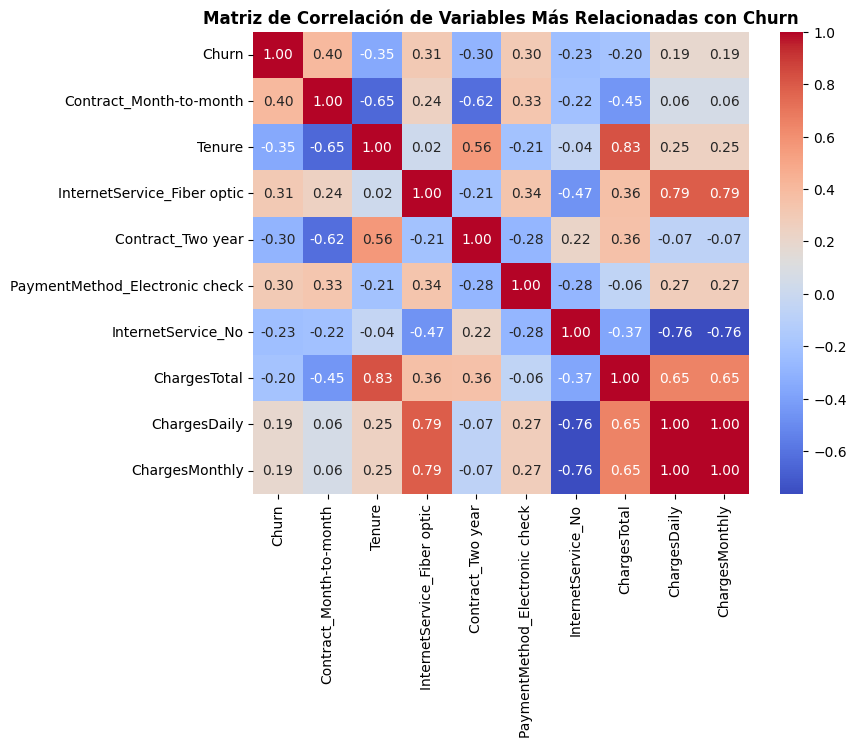

In [549]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlacion_top,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación de Variables Más Relacionadas con Churn", fontweight="bold")

plt.show()

##**Análisis Dirigido**

/tmp/ipykernel_921/378656373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="Tenure", data=df_codificado, palette="Set3")


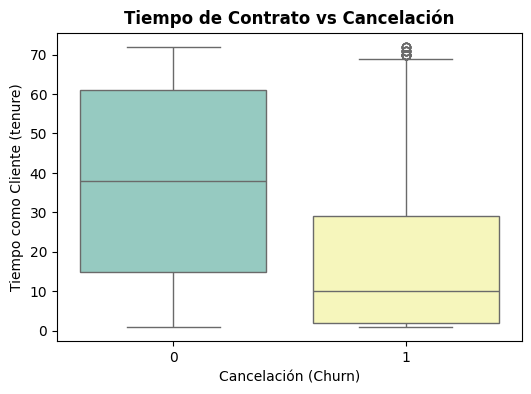

In [550]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="Tenure", data=df_codificado, palette="Set3")

plt.title("Tiempo de Contrato vs Cancelación", fontweight="bold")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Tiempo como Cliente (tenure)")

plt.show()

/tmp/ipykernel_921/2226390763.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Churn", y="ChargesTotal", data=df_codificado, palette="Set3")


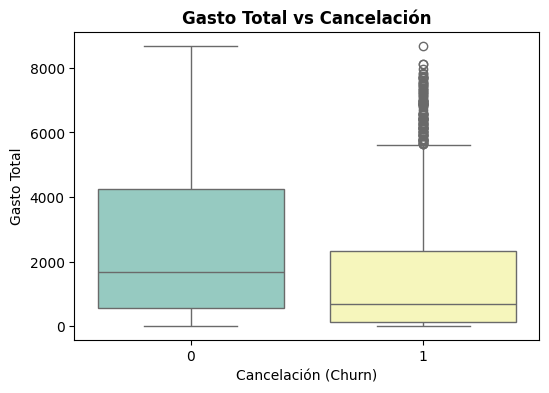

In [551]:
plt.figure(figsize=(6,4))

sns.boxplot(x="Churn", y="ChargesTotal", data=df_codificado, palette="Set3")

plt.title("Gasto Total vs Cancelación", fontweight="bold")
plt.xlabel("Cancelación (Churn)")
plt.ylabel("Gasto Total")

plt.show()

In [552]:
df_codificado1 = df_codificado.drop(columns=["ChargesTotal",
                                             "ChargesTotal",
                                             "Contract_Two year",
                                              "internet.OnlineBackup_No",
                                              "internet.OnlineBackup_Yes",
                                              "DeviceProtection_No",
                                              "DeviceProtection_Yes",
                                              "StreamingTV_Yes",
                                              "StreamingTV_No",
                                              "StreamingMovies_Yes",
                                              "StreamingMovies_No",
                                              "MultipleLines_Yes",
                                              "MultipleLines_No",
                                              "MultipleLines_No phone service",
                                              "PhoneService",
                                              "Gender_Female",
                                              "Gender_Male"])


#🤖 **Modelado Predictivo**

##**Separación de Datos**

In [553]:
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import train_test_split

X = df_codificado1.drop(['Churn'],axis=1)   #tomamos todas las variables excepto churn porque es la de respuesta
y = df_codificado1['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42) #probamos con el 30% del DF

In [554]:

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

##**Creación de Modelos**

In [555]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

M_RandomForest = RandomForestClassifier(random_state=42)
M_RandomForest.fit(X_train,y_train) #
ypred_M_RF= M_RandomForest.predict(X_test) # predicción




In [556]:
#NORMALIZACIÓN DE DATOS
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [557]:
from sklearn.linear_model import LogisticRegression

M_LogisticR = LogisticRegression(max_iter=1000)

M_LogisticR.fit(X_train_scaled, y_train)

ypred_M_LR = M_LogisticR.predict(X_test_scaled)

##**Evaluación de los Modelos**

[[1367  187]
 [ 261  295]]
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1554
           1       0.61      0.53      0.57       556

    accuracy                           0.79      2110
   macro avg       0.73      0.71      0.71      2110
weighted avg       0.78      0.79      0.78      2110



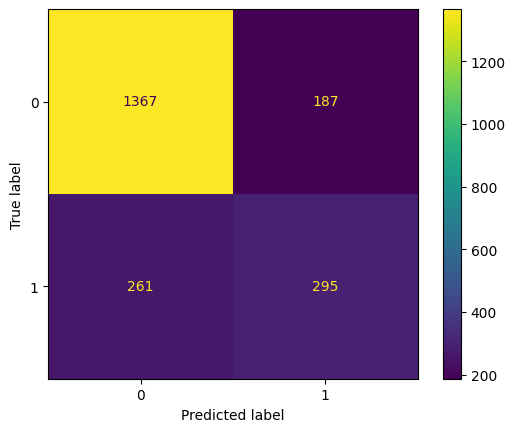

In [558]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
print(confusion_matrix(y_test, ypred_M_RF))
print(classification_report(y_test, ypred_M_RF))

ConfusionMatrixDisplay.from_predictions(y_test,ypred_M_RF);

[[1376  178]
 [ 248  308]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1554
           1       0.63      0.55      0.59       556

    accuracy                           0.80      2110
   macro avg       0.74      0.72      0.73      2110
weighted avg       0.79      0.80      0.79      2110



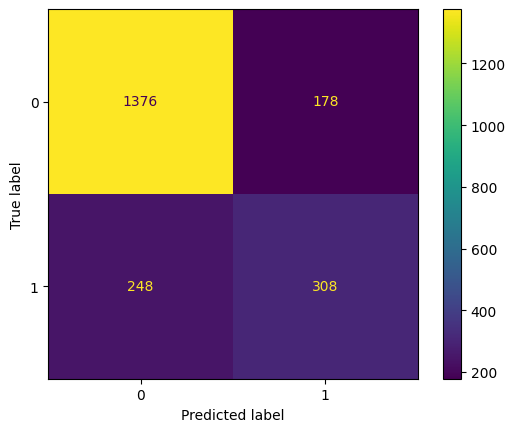

In [559]:
from sklearn.metrics import classification_report

print(confusion_matrix(y_test, ypred_M_LR))
print(classification_report(y_test, ypred_M_LR))

ConfusionMatrixDisplay.from_predictions(y_test,ypred_M_LR);

In [560]:
importances = M_RandomForest.feature_importances_

In [561]:
#
feature_importances = pd.DataFrame({'Features':X.columns,'Importances':(importances*100).round(2)}).sort_values('Importances',ascending=False)
feature_importances

,Features,Importances
3,Tenure,23.39
5,ChargesMonthly,20.27
6,ChargesDaily,20.02
14,Contract_Month-to-month,8.18
18,PaymentMethod_Electronic check,3.33
4,PaperlessBilling,2.80
8,InternetService_Fiber optic,2.64
1,Partner,2.54
2,Dependents,2.19
0,>65,2.16


In [562]:
#disponibilizamos el modelo para ser consumido
import pickle

try:
  with open('champion.pkl','wb') as file:
    pickle.dump(M_LogisticR,file)  #
  print('Modelo serializado con éxito')
except Exception as e:
  print('Se presentó un error al almacenar el modelo: ',str(e))

Modelo serializado con éxito


#📋 **Interpretación y Conclusiones**

Al comparar ambos modelos, el segundo modelo presenta un mejor desempeño general. Este modelo alcanza una accuracy del 80%, superior al 79% del primer modelo. Además, mejora el recall de la clase 1 (clientes que cancelan) de 0.53 a 0.55, lo que significa que identifica más clientes con riesgo de churn. También obtiene un mayor F1-score para esta clase (0.59 vs 0.57), mostrando un mejor equilibrio entre precisión y recall. Por estas razones, el segundo modelo es el más adecuado para predecir la cancelación de clientes.